In [ ]:
import numpy as np
import pandas as pd
from pandas import Series, DataFrame

df = pd.read_csv('../../data/train.csv')
df.head(1)

,id,LoanNr_ChkDgt,Name,City,State,Bank,BankState,ApprovalDate,ApprovalFY,NoEmp,...,CreateJob,RetainedJob,FranchiseCode,UrbanRural,RevLineCr,LowDoc,DisbursementDate,DisbursementGross,BalanceGross,Accept
0,64afe857c28,9448323000,MIDWEST CRANKSHAFT & ENGINE,HARVEY,IL,JPMORGAN CHASE BANK NATL ASSOC,IL,9-Aug-96,1996,28,...,0,0,1,0,N,N,31-Mar-97,"$600,000.00",$0.00,0
1,1705a7346c2,2854405007,"Iredesign, Limited",CHICAGO,IL,JPMORGAN CHASE BANK NATL ASSOC,IL,10-Dec-07,2008,1,...,1,1,0,1,N,N,31-Dec-07,"$25,400.00",$0.00,1
2,7439801ad8a,9300423010,PHILLY'S INC.,ROCHELLE,IL,BMO HARRIS BK NATL ASSOC,IL,23-May-96,1996,6,...,0,0,1,0,N,Y,30-Sep-96,"$20,000.00",$0.00,1
3,a3f8f9d0611,4349265000,USA Laser Imaging Inc.,Loves park,IL,ALPINE BANK & TRUST CO.,IL,4-Nov-10,2011,5,...,0,5,0,1,N,N,1-Mar-11,"$75,000.00",$0.00,1
4,71e4f243b5d,2433905006,"Dan Morrell, Inc.",LISLE,IL,JPMORGAN CHASE BANK NATL ASSOC,IL,3-May-07,2007,3,...,1,3,0,1,N,N,31-May-07,"$50,000.00",$0.00,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20763,530b1abc4d5,5400325006,OMC Construction & Restoration,MORTON GROVE,IL,JPMORGAN CHASE BANK NATL ASSOC,IL,7-Sep-12,2012,1,...,10,0,0,1,Y,N,7-Sep-12,"$45,000.00",$0.00,1
20764,d759e7e1aac,2242345001,Ronald J Wirth,ROMEOVILLE,IL,JPMORGAN CHASE BANK NATL ASSOC,IL,26-Jan-07,2007,1,...,6,4,0,1,N,N,31-Jan-07,"$55,000.00",$0.00,1
20765,d902be78167,7805983010,CHICAGO GOURMET FOODS,ELMHURST,IL,FIFTH THIRD BANK,IL,16-Nov-94,1995,8,...,0,0,1,0,N,Y,31-Jan-95,"$100,000.00",$0.00,0
20766,76adcc08afc,8905864007,"ANNIE RIVER SOLUTIONS, INC",GLEN ELLYN,IL,U.S. BANK NATIONAL ASSOCIATION,OH,6-Jun-05,2005,1,...,1,2,1,1,Y,N,30-Jun-05,"$178,634.00",$0.00,1


Query: What is the ratio of Approved vs. Denied loans?
<br>If 90% are accepted, the bank is aggressive. If 50% are denied, the bank is very conservative

        count  ratio_%
Accept                
1       16019    77.13
0        4749    22.87


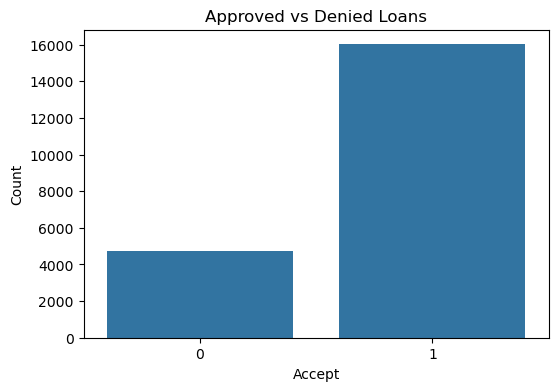

In [2]:
# What is the ratio of Approved vs. Denied loans?
import seaborn as sns
import matplotlib.pyplot as plt

counts = df['Accept'].value_counts(dropna=False)
ratios = df['Accept'].value_counts(normalize=True, dropna=False).mul(100).round(2)

summary = pd.DataFrame({'count': counts, 'ratio_%': ratios})
print(summary)

plt.figure(figsize=(6, 4))
sns.countplot(x='Accept', data=df)
plt.title('Approved vs Denied Loans')
plt.xlabel('Accept')
plt.ylabel('Count')
plt.show()

How does business maturity (NewExist) affect the outcome?
<br>Does being a "New Business" double the risk of denial? If so, Company X needs a higher score elsewhere to balance
     it out.

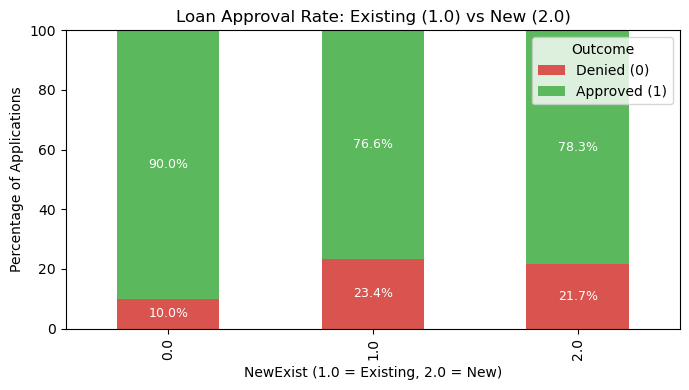

Accept,0,1
NewExist,,
0.0,10.000000,90.000000
1.0,23.416561,76.583439
2.0,21.712027,78.287973


In [3]:
# How does business maturity (NewExist) affect the outcome?
maturity_risk = (
    pd.crosstab(df['NewExist'], df['Accept'], normalize='index')
    .reindex(columns=[0, 1], fill_value=0)
    * 100
)

ax = maturity_risk.plot(
    kind='bar',
    stacked=True,
    color=['#d9534f', '#5cb85c'],
    figsize=(7, 4)
 )
ax.set_title('Loan Approval Rate: Existing (1.0) vs New (2.0)')
ax.set_xlabel('NewExist (1.0 = Existing, 2.0 = New)')
ax.set_ylabel('Percentage of Applications')
ax.set_ylim(0, 100)
ax.legend(['Denied (0)', 'Approved (1)'], title='Outcome', loc='upper right')

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='center', color='white', fontsize=9)

plt.tight_layout()
plt.show()

maturity_risk

In [6]:
# Quick check: what is NewExist = 0.0?
newexist_counts = df['NewExist'].value_counts(dropna=False).sort_index()
newexist_pct = (df['NewExist'].value_counts(dropna=False, normalize=True).sort_index() * 100).round(2)

newexist_summary = pd.DataFrame({
    'count': newexist_counts,
    'percentage_%': newexist_pct
})

print('NewExist value counts and percentages:')
display(newexist_summary)

print('\nNewExist vs Accept crosstab:')
display(pd.crosstab(df['NewExist'], df['Accept']))

NewExist value counts and percentages:


,count,percentage_%
NewExist,,
0.0,10,0.05
1.0,14178,68.27
2.0,6577,31.67
NaN,3,0.01



NewExist vs Accept crosstab:


Accept,0,1
NewExist,,
0.0,1,9
1.0,3320,10858
2.0,1428,5149


Loan Size vs. Risk (The "Skin in the Game")
<br>Is there a "Danger Zone" for loan amounts?
<br>Use log scale because loan sizes vary from $5k to $5M
Are very small loans (e.g., <$10k) denied more often (perhaps not worth the paperwork)? Or are massive loans (>$1M) the ones failing?

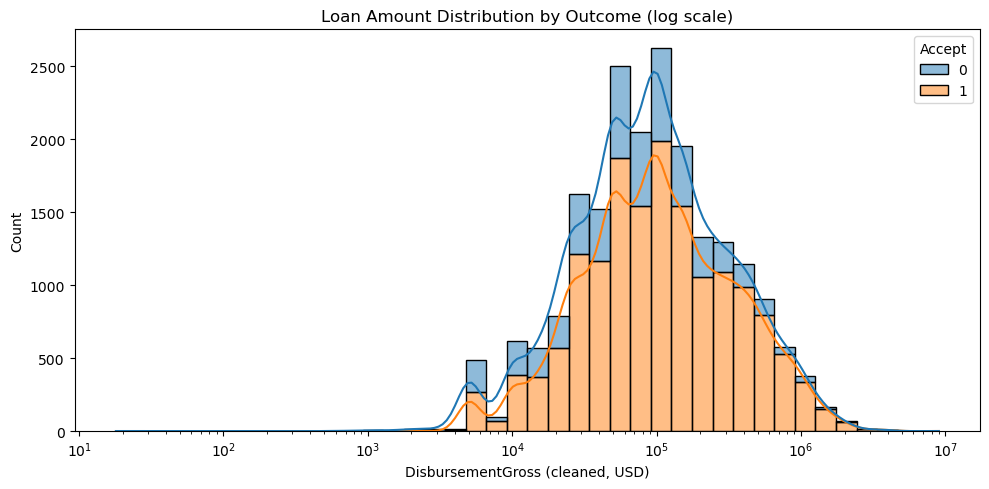

Top loan bands by denial rate:


,loan_band,applications,approval_rate,denial_rate
0,"(17.999, 20000.0]",2322,0.622308,0.377692
1,"(20000.0, 32886.8]",1832,0.740175,0.259825
2,"(50000.0, 66415.6]",1316,0.752280,0.247720
3,"(66415.6, 92964.0]",2077,0.753009,0.246991
4,"(92964.0, 116260.0]",2076,0.757707,0.242293


In [2]:
# Loan Size vs Risk: identify possible "danger zones" by loan amount
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Clean currency strings like "$123,456.00" into numeric values
df['DisbursementGross_cleaned'] = (
    df['DisbursementGross']
    .astype(str)
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
    .str.strip()
    .replace({'': np.nan})
    .astype(float)
)

# Keep only rows with valid loan amount and outcome
plot_df = df.dropna(subset=['DisbursementGross_cleaned', 'Accept']).copy()
plot_df = plot_df[plot_df['DisbursementGross_cleaned'] > 0]

plt.figure(figsize=(10, 5))
sns.histplot(
    data=plot_df,
    x='DisbursementGross_cleaned',
    hue='Accept',
    multiple='stack',
    kde=True,
    log_scale=True,
    bins=40
)
plt.title('Loan Amount Distribution by Outcome (log scale)')
plt.xlabel('DisbursementGross (cleaned, USD)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# Optional: quantify denial risk by amount bands
risk_by_band = (
    plot_df.assign(loan_band=pd.qcut(plot_df['DisbursementGross_cleaned'], q=10, duplicates='drop'))
    .groupby('loan_band', observed=False)['Accept']
    .agg(applications='size', approval_rate='mean')
    .assign(denial_rate=lambda x: 1 - x['approval_rate'])
    .sort_values('denial_rate', ascending=False)
    .reset_index()
)

print('Top loan bands by denial rate:')
display(risk_by_band.head(5))

Highest denial band: <br>
[ 18 , 20000] with denial rate ≈ 37.8% 
(approval ≈ 62.2%).<br>
Next highest: 
[20000, 32886.8] with denial rate ≈ 26.0%.<br>
Most other higher bands are around ≈ 24% − 25%.

In [8]:
# Audit DisbursementGross values before filtering with dropna
raw_disb = df['DisbursementGross']
cleaned_str = (
    raw_disb.astype(str)
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
    .str.strip()
    .replace({'': np.nan, 'nan': np.nan, 'None': np.nan})
)
cleaned_num = pd.to_numeric(cleaned_str, errors='coerce')

audit = pd.DataFrame({
    'DisbursementGross_raw': raw_disb,
    'DisbursementGross_cleaned_str': cleaned_str,
    'DisbursementGross_cleaned_num': cleaned_num,
    'Accept': df['Accept']
})

# Invalid for analysis means missing/non-numeric/non-positive loan amount
invalid_mask = audit['DisbursementGross_cleaned_num'].isna() | (audit['DisbursementGross_cleaned_num'] <= 0)
invalid_rows = audit.loc[invalid_mask].copy()

print(f"Total rows: {len(audit):,}")
print(f"Invalid DisbursementGross rows: {len(invalid_rows):,}")
print(f"Invalid share: {len(invalid_rows) / len(audit):.2%}")

print('\nBreakdown of invalid reasons:')
reason_counts = pd.Series({
    'missing_or_non_numeric': int(audit['DisbursementGross_cleaned_num'].isna().sum()),
    'non_positive_value': int((audit['DisbursementGross_cleaned_num'] <= 0).sum())
})
display(reason_counts.to_frame('count'))

print('\nSample invalid rows (up to 25):')
display(invalid_rows.head(25))

# If you want to inspect all invalid rows, uncomment:
# display(invalid_rows)

Total rows: 20,768
Invalid DisbursementGross rows: 1
Invalid share: 0.00%

Breakdown of invalid reasons:


,count
missing_or_non_numeric,0
non_positive_value,1



Sample invalid rows (up to 25):


,DisbursementGross_raw,DisbursementGross_cleaned_str,DisbursementGross_cleaned_num,Accept
11414,$0.00,0.00,0.0,0


The "Efficiency" Ratio (Employees per Dollar)
<br>Does a high loan amount relative to the number of employees signal risk?. Looking for "Outliers." A company with 1 employee (NoEmp) asking for $2,000,000 is a red flag.

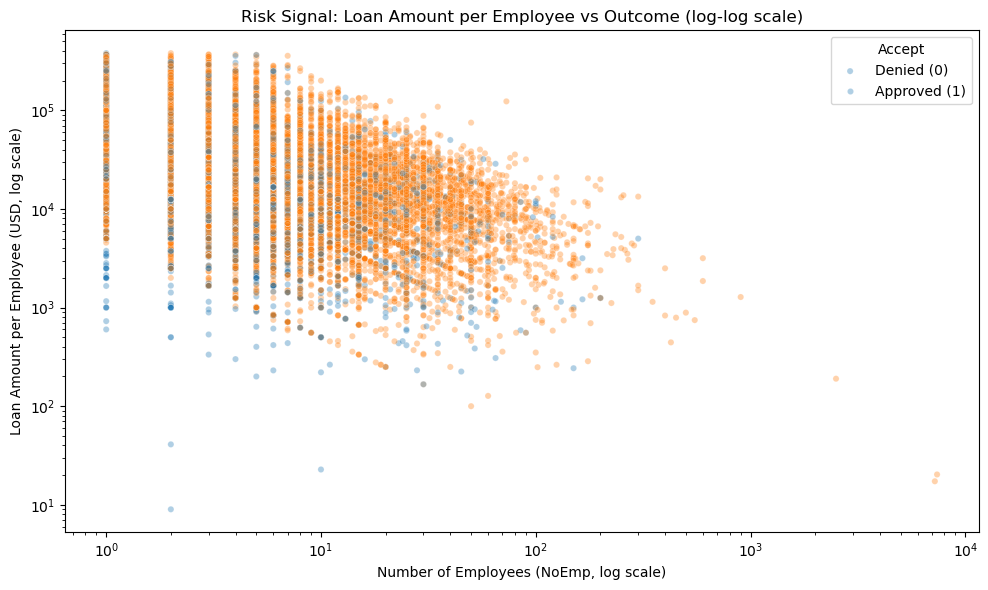

Top efficiency bands by denial rate:


,eff_band,applications,approval_rate,denial_rate
0,"(8.999, 4330.476]",2056,0.717899,0.282101
1,"(4330.476, 7500.0]",2187,0.734339,0.265661
2,"(20000.0, 25000.0]",1809,0.765616,0.234384
3,"(7500.0, 10700.2]",1924,0.776507,0.223493
4,"(85000.0, 3520000.0]",2039,0.781756,0.218244


Correlation(loan_per_employee, Accept): 0.0281 (negative means higher ratio -> lower approval)


In [10]:
# Does a high loan amount relative to number of employees signal risk?
# Build a stable metric: dollars requested per employee.
analysis_df = df.dropna(subset=['NoEmp', 'DisbursementGross_cleaned', 'Accept']).copy()
analysis_df = analysis_df[(analysis_df['NoEmp'] > 0) & (analysis_df['DisbursementGross_cleaned'] > 0)]

analysis_df['loan_per_employee'] = analysis_df['DisbursementGross_cleaned'] / analysis_df['NoEmp']

# Keep extreme outliers from dominating the chart while preserving most observations.
p99 = analysis_df['loan_per_employee'].quantile(0.99)
plot_df_eff = analysis_df[analysis_df['loan_per_employee'] <= p99].copy()

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=plot_df_eff,
    x='NoEmp',
    y='loan_per_employee',
    hue='Accept',
    alpha=0.35,
    s=20
)
plt.xscale('log')
plt.yscale('log')
plt.title('Risk Signal: Loan Amount per Employee vs Outcome (log-log scale)')
plt.xlabel('Number of Employees (NoEmp, log scale)')
plt.ylabel('Loan Amount per Employee (USD, log scale)')
plt.legend(title='Accept', labels=['Denied (0)', 'Approved (1)'])
plt.tight_layout()
plt.show()

# Quantify risk by loan-per-employee deciles (higher decile = larger amount per employee).
risk_by_eff_band = (
    analysis_df.assign(eff_band=pd.qcut(analysis_df['loan_per_employee'], q=10, duplicates='drop'))
    .groupby('eff_band', observed=False)['Accept']
    .agg(applications='size', approval_rate='mean')
    .assign(denial_rate=lambda x: 1 - x['approval_rate'])
    .sort_values('denial_rate', ascending=False)
    .reset_index()
)

print('Top efficiency bands by denial rate:')
display(risk_by_eff_band.head(5))

# Correlation check (point-biserial equivalent through binary encoding).
corr = analysis_df[['loan_per_employee', 'Accept']].corr().iloc[0, 1]
print(f"Correlation(loan_per_employee, Accept): {corr:.4f} (negative means higher ratio -> lower approval)")

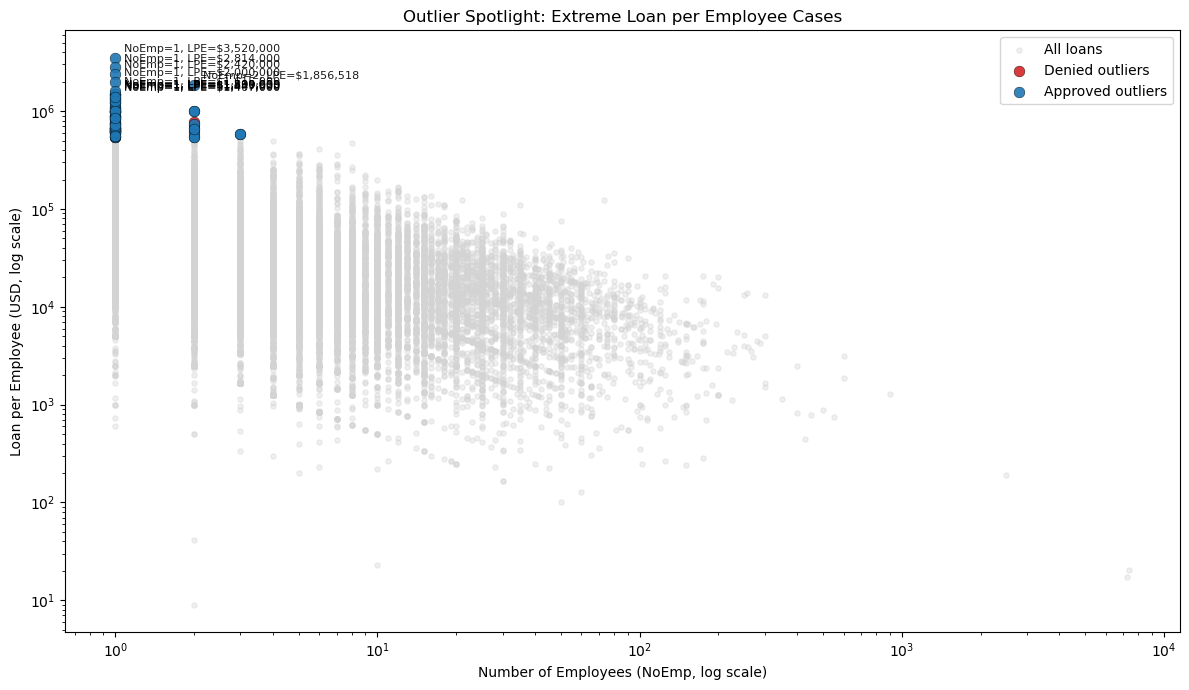

Outlier threshold (99.5th percentile): $550,000.00
Outliers shown: 107 of 20,555 rows (0.52%)


,NoEmp,DisbursementGross_cleaned,loan_per_employee,Accept
1587,1,3520000.0,3520000.0,1
5240,1,2814000.0,2814000.0,1
11332,1,2420000.0,2420000.0,1
14332,1,2000000.0,2000000.0,1
2642,2,3713037.0,1856518.5,1
16868,1,1615000.0,1615000.0,1
6432,1,1500000.0,1500000.0,1
11269,1,1500000.0,1500000.0,1
10736,1,1499000.0,1499000.0,1
3806,1,1479925.0,1479925.0,1


In [11]:
# Outlier spotlight: keep all points and make extreme loan-per-employee cases pop out
outlier_df = df.dropna(subset=['NoEmp', 'DisbursementGross_cleaned', 'Accept']).copy()
outlier_df = outlier_df[(outlier_df['NoEmp'] > 0) & (outlier_df['DisbursementGross_cleaned'] > 0)]
outlier_df['loan_per_employee'] = outlier_df['DisbursementGross_cleaned'] / outlier_df['NoEmp']

# Define outliers using a very high percentile so only the most extreme cases are highlighted
p995 = outlier_df['loan_per_employee'].quantile(0.995)
outliers = outlier_df[outlier_df['loan_per_employee'] >= p995].copy()

top_n = 12
top_outliers = outliers.nlargest(top_n, 'loan_per_employee').copy()

plt.figure(figsize=(12, 7))

# Background: all observations
plt.scatter(
    outlier_df['NoEmp'],
    outlier_df['loan_per_employee'],
    c='lightgray',
    alpha=0.35,
    s=14,
    label='All loans'
)

# Foreground: extreme outliers
palette = {0: '#d62728', 1: '#1f77b4'}
for val, label in [(0, 'Denied outliers'), (1, 'Approved outliers')]:
    d = outliers[outliers['Accept'] == val]
    if len(d) > 0:
        plt.scatter(
            d['NoEmp'],
            d['loan_per_employee'],
            c=palette[val],
            alpha=0.9,
            s=60,
            edgecolors='black',
            linewidths=0.3,
            label=label
        )

# Label the most extreme points so they are easy to inspect
for _, r in top_outliers.iterrows():
    plt.annotate(
        f"NoEmp={int(r['NoEmp'])}, LPE=${r['loan_per_employee']:,.0f}",
        (r['NoEmp'], r['loan_per_employee']),
        xytext=(6, 4),
        textcoords='offset points',
        fontsize=8,
        alpha=0.9
    )

plt.xscale('log')
plt.yscale('log')
plt.title('Outlier Spotlight: Extreme Loan per Employee Cases')
plt.xlabel('Number of Employees (NoEmp, log scale)')
plt.ylabel('Loan per Employee (USD, log scale)')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Outlier threshold (99.5th percentile): ${p995:,.2f}")
print(f"Outliers shown: {len(outliers):,} of {len(outlier_df):,} rows ({len(outliers)/len(outlier_df):.2%})")

display(top_outliers[['NoEmp', 'DisbursementGross_cleaned', 'loan_per_employee', 'Accept']].head(top_n))

In [4]:
# NoEmp audit: counts, percentages, missing values, and invalid values
noemp_raw = df['NoEmp']

# Convert to numeric safely to catch unexpected text values as invalid
noemp_num = pd.to_numeric(noemp_raw, errors='coerce')

total_rows = len(noemp_raw)
missing_mask = noemp_raw.isna()
non_numeric_mask = noemp_raw.notna() & noemp_num.isna()
non_positive_mask = noemp_num.notna() & (noemp_num <= 0)
invalid_mask_noemp = missing_mask | non_numeric_mask | non_positive_mask

# Summary counts and percentages
summary_noemp = pd.DataFrame({
    'count': [
        total_rows,
        int(missing_mask.sum()),
        int(non_numeric_mask.sum()),
        int(non_positive_mask.sum()),
        int(invalid_mask_noemp.sum()),
        int((~invalid_mask_noemp).sum())
    ]
}, index=[
    'total_rows',
    'missing',
    'non_numeric',
    'non_positive (<=0)',
    'invalid_total',
    'valid_rows'
])
summary_noemp['percentage_%'] = (summary_noemp['count'] / total_rows * 100).round(2)

print('NoEmp data quality summary:')
display(summary_noemp)

# Value distribution for valid numeric values (top 20 most common)
valid_noemp = noemp_num[~invalid_mask_noemp]
value_counts = valid_noemp.value_counts(dropna=False).sort_values(ascending=False)
value_percent = (value_counts / total_rows * 100).round(2)
noemp_distribution = pd.DataFrame({
    'NoEmp': value_counts.index,
    'count': value_counts.values,
    'percentage_of_total_%': value_percent.values
})

print('\nTop 20 most frequent NoEmp values (valid only):')
display(noemp_distribution.head(20))

# Additional descriptive stats for valid values
print('\nDescriptive stats for valid NoEmp values:')
display(valid_noemp.describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).to_frame('NoEmp'))

# Show sample invalid rows for inspection
invalid_noemp_rows = df.loc[invalid_mask_noemp, ['NoEmp', 'Accept']].copy()
print('\nSample invalid NoEmp rows (up to 20):')
display(invalid_noemp_rows.head(20))

NoEmp data quality summary:


,count,percentage_%
total_rows,20768,100.00
missing,0,0.00
non_numeric,0,0.00
non_positive (<=0),212,1.02
invalid_total,212,1.02
valid_rows,20556,98.98



Top 20 most frequent NoEmp values (valid only):


,NoEmp,count,percentage_of_total_%
0,1,3460,16.66
1,2,3320,15.99
2,3,2206,10.62
3,4,1840,8.86
4,5,1462,7.04
5,6,1052,5.07
6,10,753,3.63
7,8,710,3.42
8,7,672,3.24
9,12,473,2.28



Descriptive stats for valid NoEmp values:


,NoEmp
count,20556.000000
mean,10.895408
std,77.045620
min,1.000000
1%,1.000000
5%,1.000000
25%,2.000000
50%,4.000000
75%,10.000000
95%,38.000000



Sample invalid NoEmp rows (up to 20):


,NoEmp,Accept
70,0,1
160,0,1
239,0,1
260,0,0
358,0,1
394,0,1
414,0,1
586,0,1
740,0,0
796,0,1


Approval/Denial by NoEmp bands:


,NoEmp_band,applications,share_of_total_%,approval_rate_%,denial_rate_%
0,1,3460,16.83,70.87,29.13
1,2-5,8828,42.95,73.83,26.17
2,6-10,3553,17.28,78.41,21.59
3,11-50,4132,20.10,86.30,13.70
4,>50,583,2.84,91.77,8.23


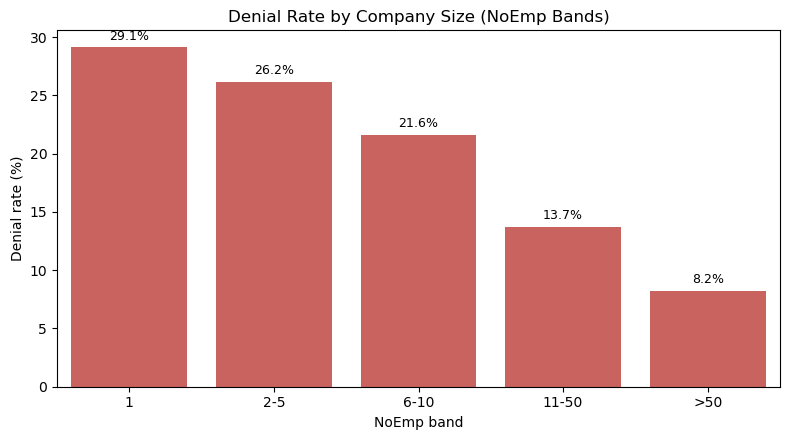

Highest denial band: 1 (29.13%) | Lowest denial band: >50 (8.23%)


In [5]:
# Approval rate by NoEmp bands: (1), (2-5), (6-10), (11-50), (>50)
noemp_band_df = df[['NoEmp', 'Accept']].copy()
noemp_band_df['NoEmp_num'] = pd.to_numeric(noemp_band_df['NoEmp'], errors='coerce')

# Keep only valid rows for this analysis
noemp_band_df = noemp_band_df[
    noemp_band_df['NoEmp_num'].notna()
    & (noemp_band_df['NoEmp_num'] > 0)
    & noemp_band_df['Accept'].notna()
].copy()

bins = [0, 1, 5, 10, 50, np.inf]
labels = ['1', '2-5', '6-10', '11-50', '>50']
noemp_band_df['NoEmp_band'] = pd.cut(noemp_band_df['NoEmp_num'], bins=bins, labels=labels, right=True)

band_summary = (
    noemp_band_df
    .groupby('NoEmp_band', observed=False)['Accept']
    .agg(applications='size', approval_rate='mean')
    .assign(denial_rate=lambda x: 1 - x['approval_rate'])
    .reset_index()
)

band_summary['approval_rate_%'] = (band_summary['approval_rate'] * 100).round(2)
band_summary['denial_rate_%'] = (band_summary['denial_rate'] * 100).round(2)
band_summary['share_of_total_%'] = (band_summary['applications'] / band_summary['applications'].sum() * 100).round(2)

print('Approval/Denial by NoEmp bands:')
display(band_summary[['NoEmp_band', 'applications', 'share_of_total_%', 'approval_rate_%', 'denial_rate_%']])

plt.figure(figsize=(8, 4.5))
ax = sns.barplot(data=band_summary, x='NoEmp_band', y='denial_rate_%', color='#d9534f')
ax.set_title('Denial Rate by Company Size (NoEmp Bands)')
ax.set_xlabel('NoEmp band')
ax.set_ylabel('Denial rate (%)')

for i, v in enumerate(band_summary['denial_rate_%']):
    ax.text(i, v + 0.4, f'{v:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Simple risk signal note
highest_risk = band_summary.sort_values('denial_rate_%', ascending=False).iloc[0]
lowest_risk = band_summary.sort_values('denial_rate_%', ascending=True).iloc[0]
print(
    f"Highest denial band: {highest_risk['NoEmp_band']} ({highest_risk['denial_rate_%']:.2f}%) | "
    f"Lowest denial band: {lowest_risk['NoEmp_band']} ({lowest_risk['denial_rate_%']:.2f}%)"
)

Categorical Risk Heatmap (LowDoc & RevLineCr)
<br>Do specific loan "programs" have higher success rates?
<br>If LowDoc = Y has a 95% approval rate, but LowDoc = N has 60%, the program itself is a huge predictor, regardless of the company's financials.

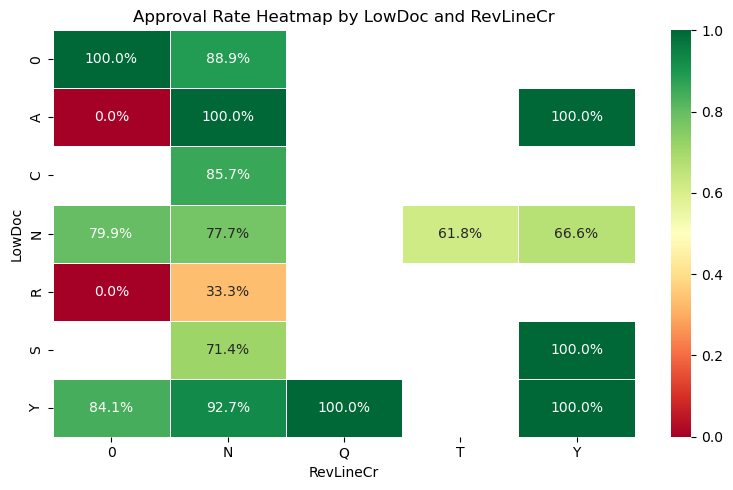

Approval rates table (%):


RevLineCr,0,N,Q,T,Y
LowDoc,,,,,
0,100.00,88.89,NaN,NaN,NaN
A,0.00,100.00,NaN,NaN,100.00
C,NaN,85.71,NaN,NaN,NaN
N,79.95,77.68,NaN,61.79,66.58
R,0.00,33.33,NaN,NaN,NaN
S,NaN,71.43,NaN,NaN,100.00
Y,84.07,92.74,100.0,NaN,100.00


In [6]:
# Approval rate by loan "program" dimensions: LowDoc x RevLineCr
analysis_cols = ['LowDoc', 'RevLineCr', 'Accept']
program_df = df[analysis_cols].dropna().copy()

# Normalize category text to avoid duplicate buckets caused by casing/spaces
program_df['LowDoc'] = program_df['LowDoc'].astype(str).str.strip().str.upper()
program_df['RevLineCr'] = program_df['RevLineCr'].astype(str).str.strip().str.upper()

pivot = program_df.pivot_table(
    index='LowDoc',
    columns='RevLineCr',
    values='Accept',
    aggfunc='mean'
).sort_index().sort_index(axis=1)

plt.figure(figsize=(8, 5))
sns.heatmap(
    pivot,
    annot=True,
    fmt='.1%',
    cmap='RdYlGn',
    vmin=0,
    vmax=1,
    linewidths=0.5,
    linecolor='white'
 )
plt.title('Approval Rate Heatmap by LowDoc and RevLineCr')
plt.xlabel('RevLineCr')
plt.ylabel('LowDoc')
plt.tight_layout()
plt.show()

print('Approval rates table (%):')
display((pivot * 100).round(2))

In [7]:
# LowDoc audit: counts, percentages, missing values, and invalid categories
lowdoc_raw = df['LowDoc']

# Standardize to string for consistent category checks
lowdoc_std = lowdoc_raw.astype('string').str.strip().str.upper()

# Missing includes true NaN and blank strings
missing_mask_lowdoc = lowdoc_raw.isna() | lowdoc_std.isna() | (lowdoc_std == '')

# Canonical valid labels for this flag
valid_values = {'Y', 'N'}
valid_mask_lowdoc = lowdoc_std.isin(valid_values)
invalid_mask_lowdoc = (~missing_mask_lowdoc) & (~valid_mask_lowdoc)

total_rows = len(df)
summary_lowdoc = pd.DataFrame(
    {'count': [
        total_rows,
        int(missing_mask_lowdoc.sum()),
        int(invalid_mask_lowdoc.sum()),
        int(valid_mask_lowdoc.sum())
    ]},
    index=['total_rows', 'missing', 'invalid_non_YN', 'valid_YN']
)
summary_lowdoc['percentage_%'] = (summary_lowdoc['count'] / total_rows * 100).round(2)

print('LowDoc data quality summary:')
display(summary_lowdoc)

# Full distribution (including missing shown as MISSING)
lowdoc_distribution = (
    lowdoc_std.fillna('MISSING')
    .replace({'': 'MISSING'})
    .value_counts(dropna=False)
    .rename_axis('LowDoc_value')
    .to_frame('count')
)
lowdoc_distribution['percentage_%'] = (lowdoc_distribution['count'] / total_rows * 100).round(2)

print('\nLowDoc value distribution (all categories):')
display(lowdoc_distribution)

print('\nSample invalid LowDoc rows (up to 20):')
display(df.loc[invalid_mask_lowdoc, ['LowDoc', 'RevLineCr', 'Accept']].head(20))

LowDoc data quality summary:


,count,percentage_%
total_rows,20768,100.00
missing,36,0.17
invalid_non_YN,51,0.25
valid_YN,20681,99.58



LowDoc value distribution (all categories):


,count,percentage_%
LowDoc_value,,
N,16903,81.39
Y,3778,18.19
MISSING,36,0.17
0,26,0.13
S,8,0.04
C,7,0.03
A,6,0.03
R,4,0.02



Sample invalid LowDoc rows (up to 20):


,LowDoc,RevLineCr,Accept
56,S,N,1
394,S,N,1
412,0,NaN,1
1413,R,N,0
1949,0,NaN,1
1959,S,N,1
2225,C,N,1
2555,0,N,1
2994,0,N,1
3779,A,Y,1


In [8]:
# RevLineCr audit: counts, percentages, missing values, and invalid categories
revline_raw = df['RevLineCr']

# Standardize to string for consistent category checks
revline_std = revline_raw.astype('string').str.strip().str.upper()

# Missing includes true NaN and blank strings
missing_mask_revline = revline_raw.isna() | revline_std.isna() | (revline_std == '')

# Canonical valid labels for this flag
valid_values_revline = {'Y', 'N'}
valid_mask_revline = revline_std.isin(valid_values_revline)
invalid_mask_revline = (~missing_mask_revline) & (~valid_mask_revline)

total_rows = len(df)
summary_revline = pd.DataFrame(
    {'count': [
        total_rows,
        int(missing_mask_revline.sum()),
        int(invalid_mask_revline.sum()),
        int(valid_mask_revline.sum())
    ]},
    index=['total_rows', 'missing', 'invalid_non_YN', 'valid_YN']
)
summary_revline['percentage_%'] = (summary_revline['count'] / total_rows * 100).round(2)

print('RevLineCr data quality summary:')
display(summary_revline)

# Full distribution (including missing shown as MISSING)
revline_distribution = (
    revline_std.fillna('MISSING')
    .replace({'': 'MISSING'})
    .value_counts(dropna=False)
    .rename_axis('RevLineCr_value')
    .to_frame('count')
)
revline_distribution['percentage_%'] = (revline_distribution['count'] / total_rows * 100).round(2)

print('\nRevLineCr value distribution (all categories):')
display(revline_distribution)

print('\nSample invalid RevLineCr rows (up to 20):')
display(df.loc[invalid_mask_revline, ['RevLineCr', 'LowDoc', 'Accept']].head(20))

RevLineCr data quality summary:


,count,percentage_%
total_rows,20768,100.00
missing,126,0.61
invalid_non_YN,5328,25.65
valid_YN,15314,73.74



RevLineCr value distribution (all categories):


,count,percentage_%
RevLineCr_value,,
N,10037,48.33
Y,5277,25.41
0,5046,24.3
T,281,1.35
MISSING,126,0.61
Q,1,0.0



Sample invalid RevLineCr rows (up to 20):


,RevLineCr,LowDoc,Accept
5,0,Y,0
9,0,N,1
11,0,N,1
13,0,N,1
16,0,N,1
17,0,N,1
24,0,Y,0
25,0,N,1
28,0,N,0
30,0,N,1


Bank column. Are there any banks that always approve loans?

How many "empty" banks have approved loans?

Disbursement_Delay (Numerical): DisbursementDate - ApprovalDate (in days).


Logic: Long delays might indicate administrative hurdles or a change in the borrower's financial health during the underwriting process.


once is approved, they give you the money no? 
Can we create a plot that can show me if the Accepted, DisbursementDate and ApprovalDate have connection?

C:\Users\nyliz\AppData\Local\Temp\ipykernel_18180\907499659.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  plot_df["ApprovalDate"] = pd.to_datetime(plot_df["ApprovalDate"], errors="coerce")
C:\Users\nyliz\AppData\Local\Temp\ipykernel_18180\907499659.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  plot_df["DisbursementDate"] = pd.to_datetime(plot_df["DisbursementDate"], errors="coerce")


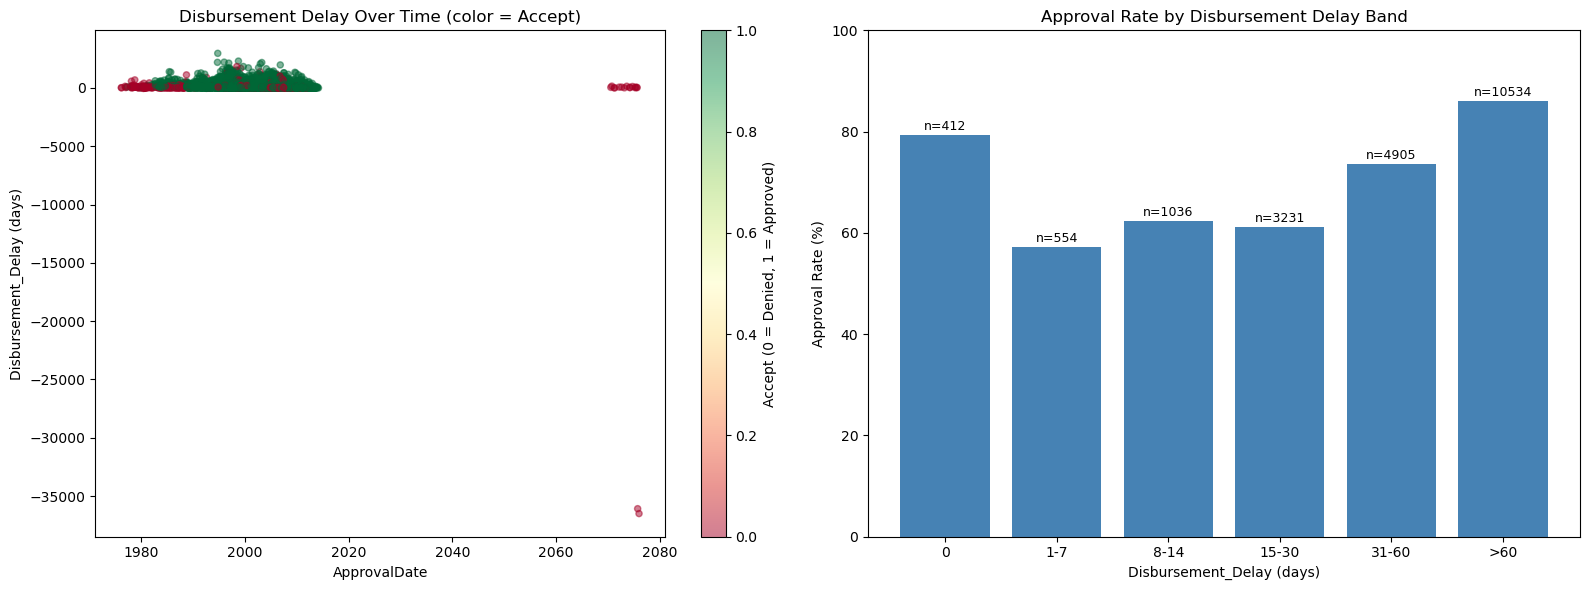

Rows used for plot: 20684
Average disbursement delay (days) by Accept:
Accept
0     56.32
1    128.34
Name: Disbursement_Delay, dtype: float64


In [12]:
# Relationship between Accept, ApprovalDate and DisbursementDate
plot_df = df[["ApprovalDate", "DisbursementDate", "Accept"]].copy()

plot_df["ApprovalDate"] = pd.to_datetime(plot_df["ApprovalDate"], errors="coerce")
plot_df["DisbursementDate"] = pd.to_datetime(plot_df["DisbursementDate"], errors="coerce")
plot_df["Disbursement_Delay"] = (
    plot_df["DisbursementDate"] - plot_df["ApprovalDate"]
).dt.days

# Keep valid rows only
plot_df = plot_df.dropna(subset=["ApprovalDate", "Disbursement_Delay", "Accept"]).copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1) Delay over approval time, colored by accepted status
scatter = axes[0].scatter(
    plot_df["ApprovalDate"],
    plot_df["Disbursement_Delay"],
    c=plot_df["Accept"],
    cmap="RdYlGn",
    alpha=0.5,
    s=20,
)
axes[0].set_title("Disbursement Delay Over Time (color = Accept)")
axes[0].set_xlabel("ApprovalDate")
axes[0].set_ylabel("Disbursement_Delay (days)")
cbar = plt.colorbar(scatter, ax=axes[0])
cbar.set_label("Accept (0 = Denied, 1 = Approved)")

# 2) Approval rate by delay band
max_delay = int(plot_df["Disbursement_Delay"].max())
upper_bin = max(61, max_delay + 1)
delay_bins = [-1, 0, 7, 14, 30, 60, upper_bin]
band_labels = ["0", "1-7", "8-14", "15-30", "31-60", ">60"]

plot_df["Delay_Band"] = pd.cut(
    plot_df["Disbursement_Delay"],
    bins=delay_bins,
    labels=band_labels,
    include_lowest=True
)

band_summary = (
    plot_df.groupby("Delay_Band", observed=False)["Accept"]
    .agg(["mean", "count"])
    .reset_index()
)
band_summary["approval_rate_pct"] = band_summary["mean"] * 100

axes[1].bar(
    band_summary["Delay_Band"].astype(str),
    band_summary["approval_rate_pct"],
    color="steelblue"
)
axes[1].set_title("Approval Rate by Disbursement Delay Band")
axes[1].set_xlabel("Disbursement_Delay (days)")
axes[1].set_ylabel("Approval Rate (%)")
axes[1].set_ylim(0, 100)

for i, row in band_summary.iterrows():
    if pd.notna(row["approval_rate_pct"]):
        axes[1].text(i, row["approval_rate_pct"] + 1, f"n={int(row['count'])}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

print("Rows used for plot:", len(plot_df))
print("Average disbursement delay (days) by Accept:")
print(plot_df.groupby("Accept")["Disbursement_Delay"].mean().round(2))

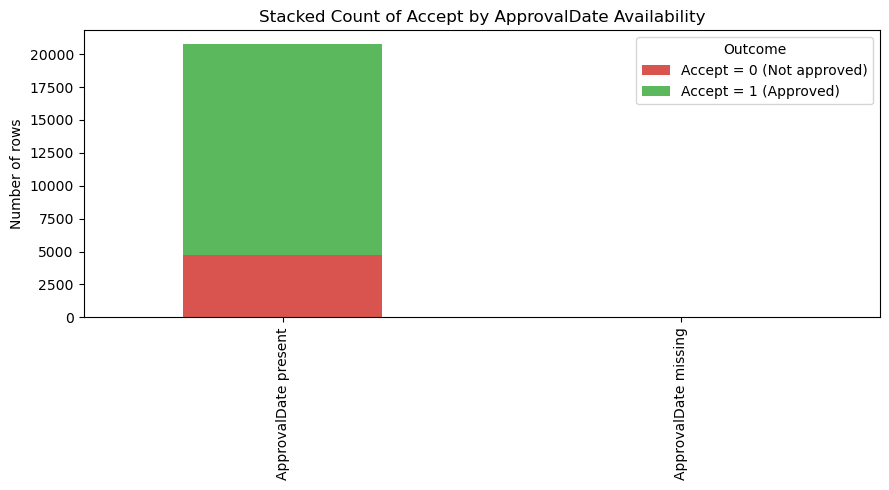

Denied rows with an ApprovalDate: 4,749
Total denied rows: 4,749
Share of denied rows that still have ApprovalDate: 100.00%

Sample denied rows that still have ApprovalDate:


,ApprovalDate,ApprovalDate_parsed,Accept
0,9-Aug-96,1996-08-09,0
4,3-May-07,2007-05-03,0
5,11-Mar-03,2003-03-11,0
10,31-Mar-03,2003-03-31,0
15,1-Apr-08,2008-04-01,0
21,4-Oct-06,2006-10-04,0
24,17-Sep-02,2002-09-17,0
28,21-May-02,2002-05-21,0
34,7-Nov-06,2006-11-07,0
36,15-Aug-05,2005-08-15,0


In [13]:
# Stacked view: Accept (0/1) by whether ApprovalDate exists
approval_check = df[["ApprovalDate", "Accept"]].copy()

# Parse dates robustly (mixed formats allowed)
approval_check["ApprovalDate_parsed"] = pd.to_datetime(
    approval_check["ApprovalDate"], errors="coerce", format="mixed"
)
approval_check["HasApprovalDate"] = approval_check["ApprovalDate_parsed"].notna()
approval_check["HasApprovalDate"] = approval_check["HasApprovalDate"].map(
    {True: "ApprovalDate present", False: "ApprovalDate missing"}
)

stack_counts = (
    approval_check.groupby(["HasApprovalDate", "Accept"], observed=False)
    .size()
    .unstack(fill_value=0)
    .reindex(index=["ApprovalDate present", "ApprovalDate missing"], fill_value=0)
)

# Ensure both classes appear in legend/order
for col in [0, 1]:
    if col not in stack_counts.columns:
        stack_counts[col] = 0
stack_counts = stack_counts[[0, 1]]

ax = stack_counts.plot(
    kind="bar",
    stacked=True,
    figsize=(9, 5),
    color=["#d9534f", "#5cb85c"]
)
ax.set_title("Stacked Count of Accept by ApprovalDate Availability")
ax.set_xlabel("")
ax.set_ylabel("Number of rows")
ax.legend(["Accept = 0 (Not approved)", "Accept = 1 (Approved)"], title="Outcome")
plt.tight_layout()
plt.show()

# Answer your exact question: rows denied but still having ApprovalDate
denied_with_date = approval_check[
    (approval_check["Accept"] == 0) & (approval_check["ApprovalDate_parsed"].notna())
].copy()

print(f"Denied rows with an ApprovalDate: {len(denied_with_date):,}")
print(f"Total denied rows: {(approval_check['Accept'] == 0).sum():,}")
if (approval_check['Accept'] == 0).sum() > 0:
    pct = len(denied_with_date) / (approval_check['Accept'] == 0).sum() * 100
    print(f"Share of denied rows that still have ApprovalDate: {pct:.2f}%")

print("\nSample denied rows that still have ApprovalDate:")
display(
    denied_with_date[["ApprovalDate", "ApprovalDate_parsed", "Accept"]].head(10)
)

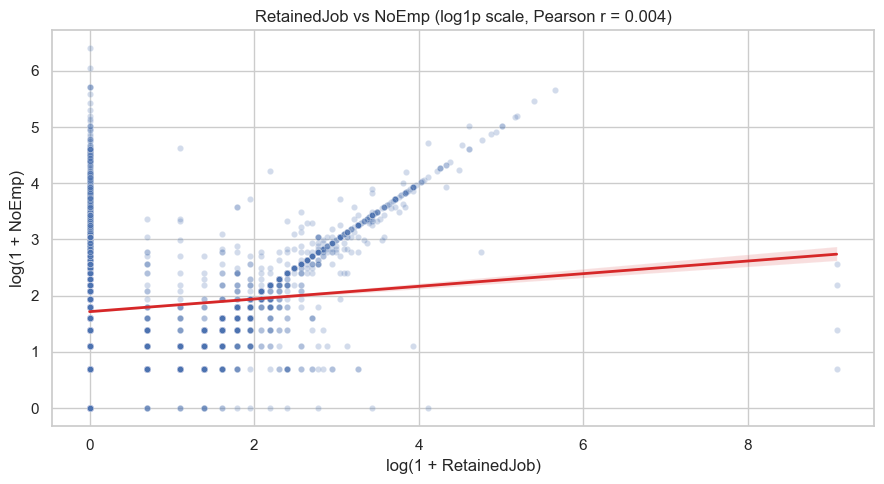

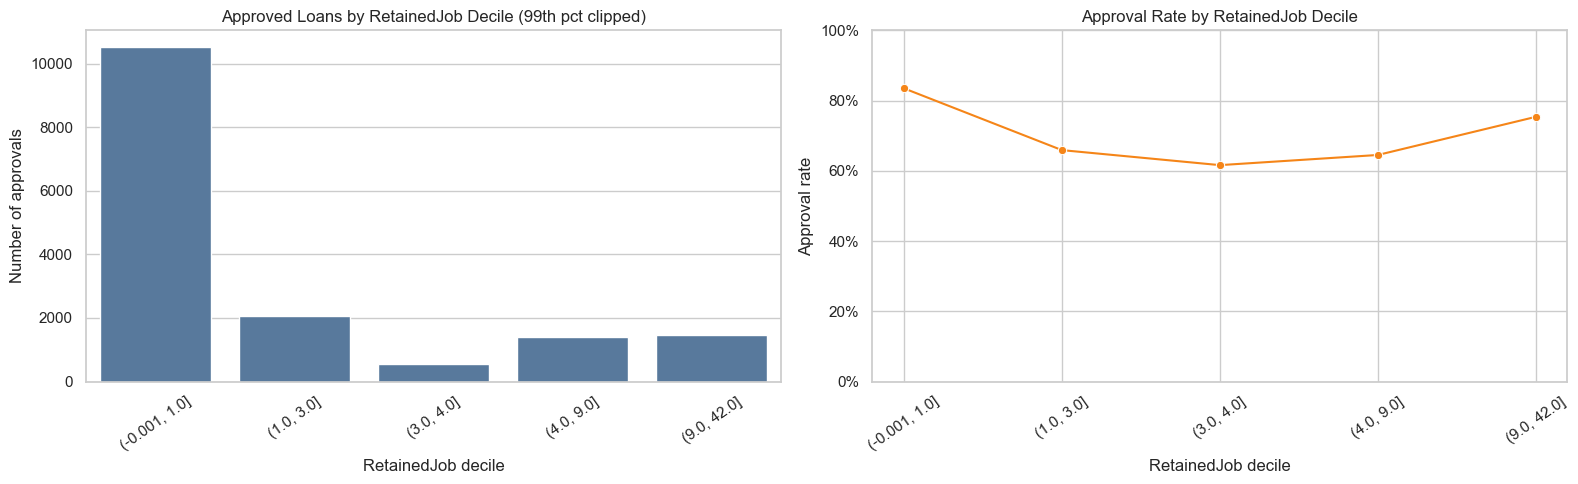

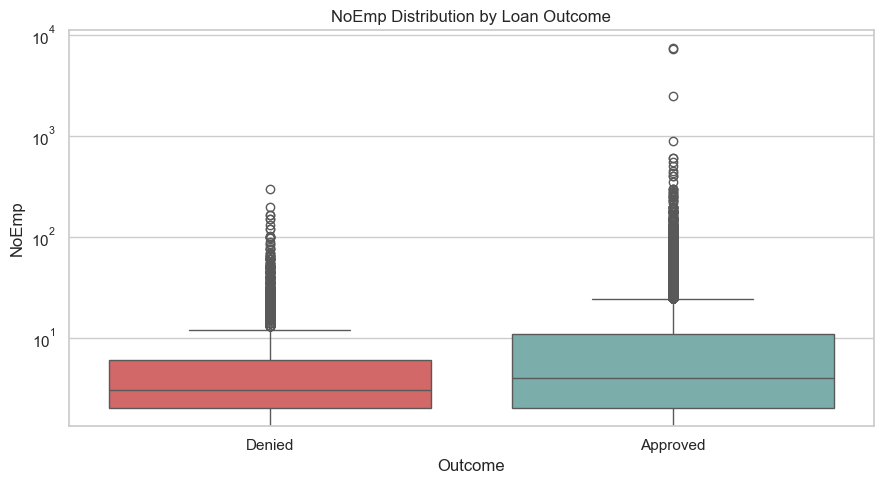

,RetainedJobBin,total,approvals,approval_rate
0,"(-0.001, 1.0]",12603,10524,0.835039
1,"(1.0, 3.0]",3153,2078,0.659055
2,"(3.0, 4.0]",920,567,0.616304
3,"(4.0, 9.0]",2162,1395,0.645236
4,"(9.0, 42.0]",1930,1455,0.753886


In [5]:
# RetainedJob vs NoEmp, and impact on Accept
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

analysis = df[["RetainedJob", "NoEmp", "Accept"]].copy()
analysis["RetainedJob"] = pd.to_numeric(analysis["RetainedJob"], errors="coerce")
analysis["NoEmp"] = pd.to_numeric(analysis["NoEmp"], errors="coerce")
analysis["Accept"] = pd.to_numeric(analysis["Accept"], errors="coerce")
analysis = analysis.dropna(subset=["RetainedJob", "NoEmp", "Accept"])

if analysis.empty:
    print("No valid rows found after cleaning RetainedJob/NoEmp/Accept.")
else:
    sns.set_theme(style="whitegrid")

    # Keep labels consistent and robust for plotting
    analysis["AcceptInt"] = analysis["Accept"].round().astype(int)
    analysis["AcceptLabel"] = analysis["AcceptInt"].map({0: "Denied", 1: "Approved"}).fillna("Other")

    # 1) Relationship between RetainedJob and NoEmp (log view to handle heavy skew/outliers)
    corr = analysis[["RetainedJob", "NoEmp"]].corr().loc["RetainedJob", "NoEmp"]
    plot_rel = analysis[(analysis["RetainedJob"] >= 0) & (analysis["NoEmp"] >= 0)].copy()
    plot_rel["RetainedJob_log1p"] = np.log1p(plot_rel["RetainedJob"])
    plot_rel["NoEmp_log1p"] = np.log1p(plot_rel["NoEmp"])

    plt.figure(figsize=(9, 5))
    sns.scatterplot(
        data=plot_rel.sample(min(len(plot_rel), 6000), random_state=42) if len(plot_rel) > 0 else plot_rel,
        x="RetainedJob_log1p",
        y="NoEmp_log1p",
        alpha=0.25,
        s=20
    )
    sns.regplot(
        data=plot_rel,
        x="RetainedJob_log1p",
        y="NoEmp_log1p",
        scatter=False,
        line_kws={"color": "#d62728", "lw": 2}
    )
    plt.title(f"RetainedJob vs NoEmp (log1p scale, Pearson r = {corr:.3f})")
    plt.xlabel("log(1 + RetainedJob)")
    plt.ylabel("log(1 + NoEmp)")
    plt.tight_layout()
    plt.show()

    # 2) Effect of RetainedJob on approvals: bin RetainedJob to show stable approval rates
    q = analysis["RetainedJob"].quantile(0.99)
    clipped = analysis.copy()
    clipped["RetainedJob_clipped"] = clipped["RetainedJob"].clip(upper=q)

    clipped["RetainedJobBin"] = pd.qcut(
        clipped["RetainedJob_clipped"],
        q=10,
        duplicates="drop"
    )

    agg_bin = (
        clipped.groupby("RetainedJobBin", observed=False)["AcceptInt"]
        .agg(total="count", approvals="sum")
        .reset_index()
    )
    agg_bin["approval_rate"] = agg_bin["approvals"] / agg_bin["total"]
    agg_bin["bin_label"] = agg_bin["RetainedJobBin"].astype(str)

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    sns.barplot(data=agg_bin, x="bin_label", y="approvals", color="#4c78a8", ax=axes[0])
    axes[0].set_title("Approved Loans by RetainedJob Decile (99th pct clipped)")
    axes[0].set_xlabel("RetainedJob decile")
    axes[0].set_ylabel("Number of approvals")
    axes[0].tick_params(axis="x", rotation=35)

    sns.lineplot(
        data=agg_bin,
        x="bin_label",
        y="approval_rate",
        marker="o",
        color="#f58518",
        ax=axes[1]
    )
    axes[1].set_title("Approval Rate by RetainedJob Decile")
    axes[1].set_xlabel("RetainedJob decile")
    axes[1].set_ylabel("Approval rate")
    axes[1].set_ylim(0, 1)
    axes[1].tick_params(axis="x", rotation=35)
    axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))

    plt.tight_layout()
    plt.show()

    # 3) NoEmp distribution by approval outcome
    plt.figure(figsize=(9, 5))
    sns.boxplot(
        data=analysis[analysis["AcceptLabel"].isin(["Denied", "Approved"])],
        x="AcceptLabel",
        y="NoEmp",
        hue="AcceptLabel",
        legend=False,
        palette={"Denied": "#e45756", "Approved": "#72b7b2"}
    )
    plt.title("NoEmp Distribution by Loan Outcome")
    plt.xlabel("Outcome")
    plt.ylabel("NoEmp")
    plt.yscale("log")
    plt.tight_layout()
    plt.show()

    display(agg_bin[["RetainedJobBin", "total", "approvals", "approval_rate"]])

Rows used: 20,768
Overall Accept = 0 rate: 22.87%

BankState - highest Accept = 0 groups (min 100 rows)


,BankStateLabel,total,denied,denied_rate
3,CA,1324,700,0.528701
7,DE,663,344,0.518854
32,RI,1334,581,0.435532
39,VA,567,241,0.425044
21,NC,443,183,0.413093
26,NY,348,117,0.336207
34,SD,429,108,0.251748
27,OH,1105,275,0.248869
36,TX,249,59,0.236948
19,MO,124,25,0.201613


NewExist - highest Accept = 0 groups (min 50 rows)


,NewExistLabel,total,denied,denied_rate
0,Existing business,14178,3320,0.234166
1,New business,6577,1428,0.217120


FranchiseCode - highest Accept = 0 groups (min 50 rows)


...

,bucket,total,denied,denied_rate
2,"(1.386, 1.609]",920,353,0.383696
3,"(1.609, 2.303]",2162,767,0.354764
1,"(0.693, 1.386]",3153,1075,0.340945
4,"(2.303, 9.083]",1930,475,0.246114
0,"(-0.001, 0.693]",12603,2079,0.164961


DisbursementGross - highest Accept = 0 buckets


,bucket,total,denied,denied_rate
0,"(-0.001, 9.904]",2323,878,0.377960
1,"(9.904, 10.401]",1831,476,0.259967
3,"(10.82, 11.103]",1316,326,0.247720
4,"(11.103, 11.439]",2076,513,0.247110
5,"(11.439, 11.664]",2077,503,0.242176
2,"(10.401, 10.82]",2838,687,0.242072
6,"(11.664, 11.984]",2076,437,0.210501
7,"(11.984, 12.468]",2084,428,0.205374
8,"(12.468, 13.071]",2078,288,0.138595
9,"(13.071, 16.012]",2069,213,0.102948


BalanceGross: not enough variation for binning
Binary zero-flag combinations with highest Accept = 0 rate


,NoEmp_is_zero,CreateJob_is_zero,RetainedJob_is_zero,BalanceGross_is_zero,total,denied,denied_rate
0,0,0,0,1,5188,1832,0.353123
6,1,1,0,1,20,7,0.350000
2,0,1,0,1,5021,1579,0.314479
4,1,0,0,1,55,15,0.272727
7,1,1,1,1,70,15,0.214286
5,1,0,1,1,67,13,0.194030
3,0,1,1,1,8808,1184,0.134423
1,0,0,1,1,1539,104,0.067576


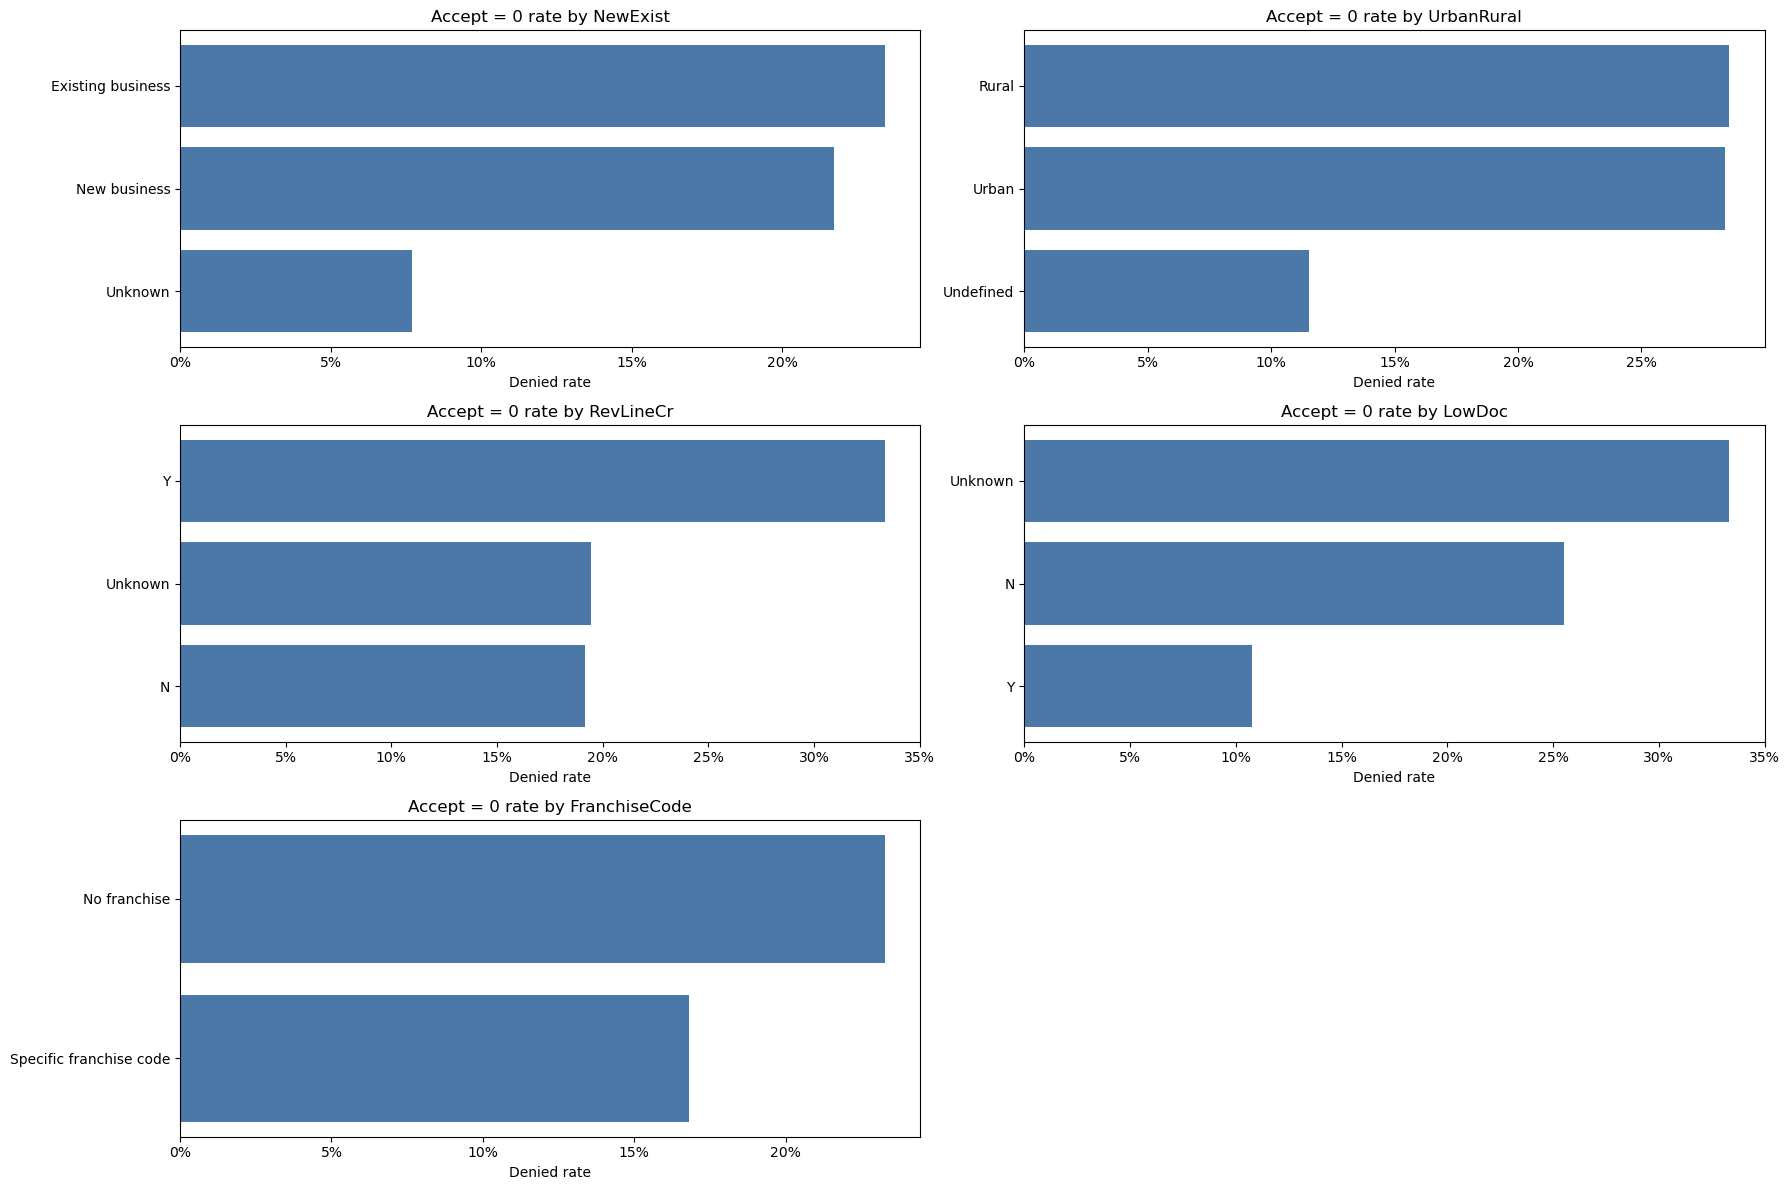

Top denial-prone options across the requested columns


,Feature,BankStateLabel,total,denied,denied_rate,NewExistLabel,FranchiseLabel,UrbanRuralLabel,RevLineCrLabel,LowDocLabel,bucket
0,BankState,CA,1324,700,0.528701,NaN,NaN,NaN,<NA>,<NA>,NaN
1,BankState,DE,663,344,0.518854,NaN,NaN,NaN,<NA>,<NA>,NaN
2,BankState,RI,1334,581,0.435532,NaN,NaN,NaN,<NA>,<NA>,NaN
3,BankState,VA,567,241,0.425044,NaN,NaN,NaN,<NA>,<NA>,NaN
4,BankState,NC,443,183,0.413093,NaN,NaN,NaN,<NA>,<NA>,NaN
27,RetainedJob,<NA>,920,353,0.383696,NaN,NaN,NaN,<NA>,<NA>,"(1.386, 1.609]"
32,DisbursementGross,<NA>,2323,878,0.377960,NaN,NaN,NaN,<NA>,<NA>,"(-0.001, 9.904]"
23,CreateJob,<NA>,1475,528,0.357966,NaN,NaN,NaN,<NA>,<NA>,"(0.693, 1.099]"
28,RetainedJob,<NA>,2162,767,0.354764,NaN,NaN,NaN,<NA>,<NA>,"(1.609, 2.303]"
29,RetainedJob,<NA>,3153,1075,0.340945,NaN,NaN,NaN,<NA>,<NA>,"(0.693, 1.386]"


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from IPython.display import display

# Keep this cell self-contained and limited to the requested columns.
required_cols = [
    "BankState",
    "NoEmp",
    "NewExist",
    "CreateJob",
    "RetainedJob",
    "FranchiseCode",
    "UrbanRural",
    "RevLineCr",
    "LowDoc",
    "DisbursementGross",
    "BalanceGross",
    "Accept",
]


def resolve_train_path() -> Path:
    for base in [Path.cwd(), *Path.cwd().parents]:
        candidate = base / "data" / "train.csv"
        if candidate.exists():
            return candidate
    raise FileNotFoundError("Could not locate data/train.csv from the current notebook working directory.")


if "df" not in globals() or not isinstance(df, pd.DataFrame):
    df = pd.read_csv(resolve_train_path())

analysis = df[required_cols].copy()

# Normalize the target and keep only valid labels.
analysis["Accept"] = pd.to_numeric(analysis["Accept"], errors="coerce")
analysis = analysis[analysis["Accept"].isin([0, 1])].copy()
analysis["AcceptInt"] = analysis["Accept"].astype(int)
analysis["Denied"] = (analysis["AcceptInt"] == 0).astype(int)

# Clean the columns described in about-data.md.
for col in ["BankState", "RevLineCr", "LowDoc"]:
    analysis[col] = analysis[col].astype("string").str.strip().str.upper()

for col in ["NoEmp", "NewExist", "CreateJob", "RetainedJob", "FranchiseCode", "UrbanRural", "DisbursementGross", "BalanceGross"]:
    analysis[col] = (
        analysis[col]
        .astype("string")
        .str.replace(r"[^0-9\.-]", "", regex=True)
        .replace("", np.nan)
    )
    analysis[col] = pd.to_numeric(analysis[col], errors="coerce")

analysis["NewExistLabel"] = analysis["NewExist"].map({1: "Existing business", 2: "New business"}).fillna("Unknown")
analysis["UrbanRuralLabel"] = analysis["UrbanRural"].map({0: "Undefined", 1: "Urban", 2: "Rural"}).fillna("Unknown")
analysis["RevLineCrLabel"] = analysis["RevLineCr"].where(analysis["RevLineCr"].isin(["Y", "N"]), "Unknown")
analysis["LowDocLabel"] = analysis["LowDoc"].where(analysis["LowDoc"].isin(["Y", "N"]), "Unknown")
analysis["FranchiseLabel"] = np.where(analysis["FranchiseCode"].isin([0, 1]), "No franchise", "Specific franchise code")
analysis.loc[analysis["FranchiseCode"].isna(), "FranchiseLabel"] = "Unknown"
analysis["BankStateLabel"] = analysis["BankState"].fillna("Unknown")

overall = analysis["Denied"].mean()
print(f"Rows used: {len(analysis):,}")
print(f"Overall Accept = 0 rate: {overall:.2%}")
print()

# Categorical risk audit: show the most denial-prone options for each column.
def top_denial_groups(frame, feature, label=None, min_count=50, top_n=8):
    label = label or feature
    summary = (
        frame.groupby(feature, dropna=False)
        .agg(
            total=("Denied", "size"),
            denied=("Denied", "sum"),
            denied_rate=("Denied", "mean"),
        )
        .reset_index()
        .sort_values(["denied_rate", "total"], ascending=[False, False])
    )
    summary = summary[summary["total"] >= min_count].head(top_n)
    if summary.empty:
        print(f"{label}: no groups with at least {min_count} rows")
        return summary
    print(f"{label} - highest Accept = 0 groups (min {min_count} rows)")
    display(summary)
    return summary

cat_tables = [
    top_denial_groups(analysis, "BankStateLabel", "BankState", min_count=100, top_n=10),
    top_denial_groups(analysis, "NewExistLabel", "NewExist", min_count=50, top_n=10),
    top_denial_groups(analysis, "FranchiseLabel", "FranchiseCode", min_count=50, top_n=10),
    top_denial_groups(analysis, "UrbanRuralLabel", "UrbanRural", min_count=50, top_n=10),
    top_denial_groups(analysis, "RevLineCrLabel", "RevLineCr", min_count=50, top_n=10),
    top_denial_groups(analysis, "LowDocLabel", "LowDoc", min_count=50, top_n=10),
]

# Numeric risk audit: bin continuous values and measure denial rate by bucket.
def binned_denial_audit(frame, feature, bins=10, min_count=50, log1p=False):
    series = frame[feature].copy()
    if log1p:
        series = np.log1p(series.clip(lower=0))
    valid = frame.loc[series.notna(), ["Denied"]].copy()
    valid["bucket_source"] = series.loc[series.notna()]
    if valid["bucket_source"].nunique() < 3:
        print(f"{feature}: not enough variation for binning")
        return pd.DataFrame()
    try:
        valid["bucket"] = pd.qcut(valid["bucket_source"], q=bins, duplicates="drop")
    except ValueError:
        valid["bucket"] = pd.cut(valid["bucket_source"], bins=min(bins, valid["bucket_source"].nunique()))
    summary = (
        valid.groupby("bucket", observed=False)
        .agg(total=("Denied", "size"), denied=("Denied", "sum"), denied_rate=("Denied", "mean"))
        .reset_index()
        .sort_values(["denied_rate", "total"], ascending=[False, False])
    )
    summary = summary[summary["total"] >= min_count]
    print(f"{feature} - highest Accept = 0 buckets")
    display(summary.head(10))
    return summary

num_tables = [
    binned_denial_audit(analysis, "NoEmp", bins=10, min_count=100, log1p=True),
    binned_denial_audit(analysis, "CreateJob", bins=10, min_count=100, log1p=True),
    binned_denial_audit(analysis, "RetainedJob", bins=10, min_count=100, log1p=True),
    binned_denial_audit(analysis, "DisbursementGross", bins=10, min_count=100, log1p=True),
    binned_denial_audit(analysis, "BalanceGross", bins=10, min_count=25, log1p=True),
]

# Quick flags that are often informative for denial behavior.
analysis["NoEmp_is_zero"] = (analysis["NoEmp"] == 0).astype(int)
analysis["CreateJob_is_zero"] = (analysis["CreateJob"] == 0).astype(int)
analysis["RetainedJob_is_zero"] = (analysis["RetainedJob"] == 0).astype(int)
analysis["BalanceGross_is_zero"] = (analysis["BalanceGross"] == 0).astype(int)

flag_summary = (
    analysis.groupby(["NoEmp_is_zero", "CreateJob_is_zero", "RetainedJob_is_zero", "BalanceGross_is_zero"], dropna=False)
    .agg(total=("Denied", "size"), denied=("Denied", "sum"), denied_rate=("Denied", "mean"))
    .reset_index()
    .sort_values(["denied_rate", "total"], ascending=[False, False])
)
print("Binary zero-flag combinations with highest Accept = 0 rate")
display(flag_summary.head(10))

# Compact visual summary for the strongest categorical signals.
plot_frames = []
for feature, column in [
    ("NewExist", "NewExistLabel"),
    ("UrbanRural", "UrbanRuralLabel"),
    ("RevLineCr", "RevLineCrLabel"),
    ("LowDoc", "LowDocLabel"),
    ("FranchiseCode", "FranchiseLabel"),
]:
    temp = (
        analysis.groupby(column, dropna=False)["Denied"]
        .mean()
        .rename("DeniedRate")
        .reset_index()
        .rename(columns={column: "Option"})
    )
    temp["Feature"] = feature
    plot_frames.append(temp)

plot_source = pd.concat(plot_frames, ignore_index=True)
fig, axes = plt.subplots(3, 2, figsize=(18, 12))
axes = axes.flatten()
for ax, feature in zip(axes, ["NewExist", "UrbanRural", "RevLineCr", "LowDoc", "FranchiseCode"]):
    subset = plot_source[plot_source["Feature"] == feature].sort_values("DeniedRate", ascending=False)
    ax.barh(subset["Option"].astype(str), subset["DeniedRate"], color="#4c78a8")
    ax.invert_yaxis()
    ax.set_title(f"Accept = 0 rate by {feature}")
    ax.set_xlabel("Denied rate")
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))

axes[-1].axis("off")
plt.tight_layout()
plt.show()

# Final compact takeaway table: highest denial-rate buckets across all audited groups.
all_tables = []
for feature, table in [
    ("BankState", cat_tables[0]),
    ("NewExist", cat_tables[1]),
    ("FranchiseCode", cat_tables[2]),
    ("UrbanRural", cat_tables[3]),
    ("RevLineCr", cat_tables[4]),
    ("LowDoc", cat_tables[5]),
    ("NoEmp", num_tables[0]),
    ("CreateJob", num_tables[1]),
    ("RetainedJob", num_tables[2]),
    ("DisbursementGross", num_tables[3]),
    ("BalanceGross", num_tables[4]),
]:
    if table is not None and len(table) > 0:
        temp = table.head(5).copy()
        temp.insert(0, "Feature", feature)
        all_tables.append(temp)

if all_tables:
    takeaway = pd.concat(all_tables, ignore_index=True)
    print("Top denial-prone options across the requested columns")
    display(takeaway.sort_values(["denied_rate", "total"], ascending=[False, False]).head(20))
else:
    print("No stable groups found for the requested denial audit.")